# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

Предоставлены данные о последней маркетинговой кампании, которую проводил банк: задачей было привлечь клиентов для открытия депозита. Необходимо проанализировать эти данные, выявить закономерность и найти решающие факторы, повлиявшие на то, что клиент вложил деньги именно в этот банк. Если вы сможете это сделать, то поднимете доходы банка и поможете понять целевую аудиторию, которую необходимо привлекать путём рекламы и различных предложений.

### Данные о клиентах банка:

* age (возраст);
* job (сфера занятости);
* marital (семейное положение);
* education (уровень образования);
* default (имеется ли просроченный кредит);
* housing (имеется ли кредит на жильё);
* loan (имеется ли кредит на личные нужды);
* balance (баланс).

### Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:

* contact (тип контакта с клиентом);
* month (месяц, в котором был последний контакт);
* day (день, в который был последний контакт);
* duration (продолжительность контакта в секундах).

### Прочие признаки:

* campaign (количество контактов с этим клиентом в течение текущей кампании);
* pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
* previous (количество контактов до текущей кампании)
* poutcome (результат прошлой маркетинговой кампании).

И, разумеется, наша целевая переменная `deposit`, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.



In [2]:
df = pd.read_csv('data/bank_fin.zip', sep = ';')
display(df.head(5))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


None

In [4]:

display(df.isnull().sum())

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

In [5]:

display(df['job'].value_counts())


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

In [6]:
display(df['education'].value_counts())


education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

In [7]:
# Преобразуем признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = df['balance'].apply (lambda x: float(str(x).replace('$','').replace(' ','').replace(',','.')))


In [8]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку

med_bal = df['balance'].median()
df['balance'].fillna(med_bal, inplace=True)

In [9]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения

df['job'] = df['job'].replace('unknown', 'management')
df['education'] = df['education'].replace('unknown', 'secondary')


In [10]:
display(df['job'].value_counts())
display(df['education'].value_counts())

job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
Name: count, dtype: int64

education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64

In [11]:
# удалите все выбросы для признака balance
# Применим заготовленную функцию для удаления выбросов методом Тьюки:

def drop_iqr(df, col, left=1.5, right=1.5, log_scale=False, add_one=False):
    """Drop outliers using the interquartile range method (Tukey's method)

    Args:
        df (DataFrame): pandas DataFrame
        col (str): column name
        log_scale (bool, optional): converting to the natural log scale. 
                                    Defaults to False.
        add_one (bool, optional): add 1 to all values, 
                                  (works for the log scale only,
                                  usefull if there are zeros in data). 
                                  Defaults to False.
        left (float, optional): lower IQR bound. Defaults to 1.5.
        right (float, optional): upper IQR bound. Defaults to 1.5.

    Returns:
        tuple: a tuple containing the cleaned dataframe, the calculated 
               lower and upper bounds, and the dataframe with outliers
    """
    
    if log_scale and add_one:
        x = np.log(df[col]+1)
    elif log_scale and not add_one:
        x = np.log(df[col])
    else:
        x = df[col]
    
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr*left)
    upper_bound = quartile_3 + (iqr*right)
    outliers = df[(x<lower_bound) | (x>upper_bound)]
    clean_df = df[(x>=lower_bound) & (x<=upper_bound)]
    
    return clean_df, lower_bound, upper_bound, outliers


df, lower_bound, upper_bound, _ = drop_iqr(df, 'balance')
print(lower_bound, upper_bound, df.shape[0])



-2241.0 4063.0 10105


## Часть 2:  Разведывательный анализ

--- Абсолютные значения ---
deposit
no     5424
yes    4681
Name: count, dtype: int64

--- Пропорции (доли) ---
deposit
no     0.536764
yes    0.463236
Name: proportion, dtype: float64


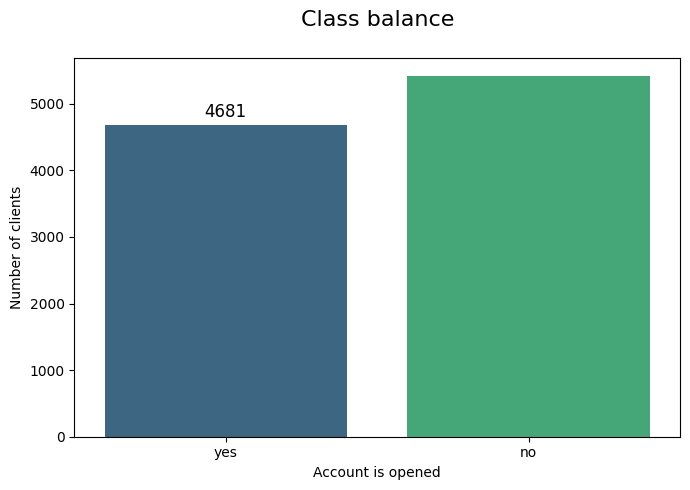

In [12]:
# Изучим соотношение классов в данных на предмет несбалансированности, проиллюстрируем результат.
# Сначала выведем текстовые данные в консоль, чтобы они точно напечатались
print("--- Абсолютные значения ---")
print(df['deposit'].value_counts())
print("\n--- Пропорции (доли) ---")
print(df['deposit'].value_counts(normalize=True))

# Настраиваем размер графика
plt.figure(figsize=(7, 5))

# Строим график (в современных версиях Seaborn нужно явно указывать x=...)
ax = sns.countplot(x=df['deposit'], palette='viridis')

# ВАЖНО: Добавляем точные подписи количества прямо НА столбики!
ax.bar_label(ax.containers[0], fontsize=12, padding=3)

# Наводим красоту
ax.set(xlabel='Account is opened', ylabel='Number of clients')
ax.set_title('Class balance\n', fontsize=16)

plt.tight_layout()
plt.show()


,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


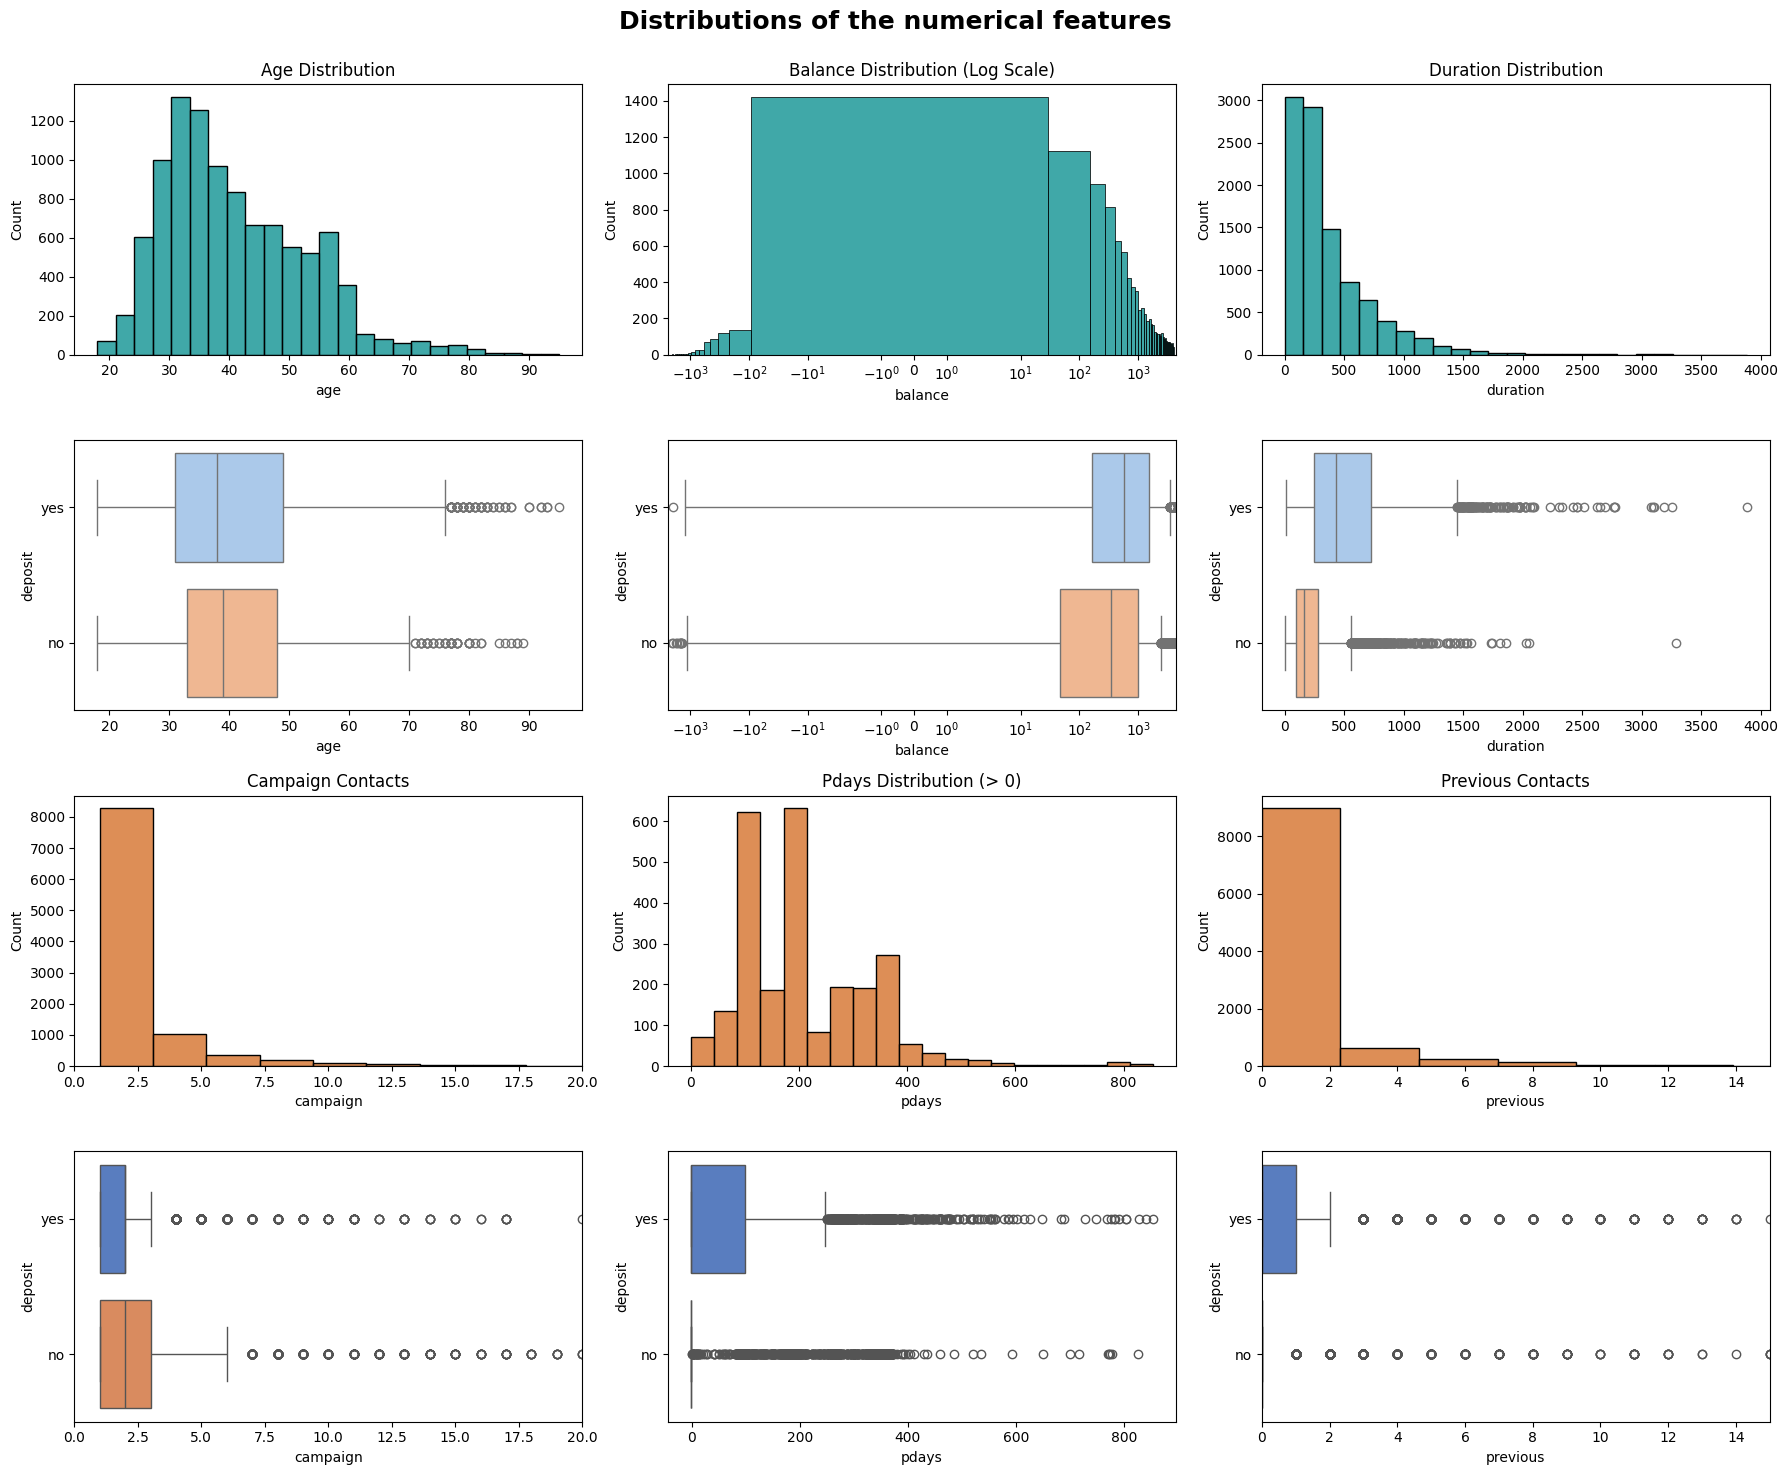

In [13]:
# Рассчитаем описательные статистики для количественных переменных, проинтерпретируем результат
# 1. Сначала выводим описательную статистику
display(df.describe())

# 2. Создаем сетку графиков 4 строки на 3 колонки
fig, ax = plt.subplots(4, 3, figsize=(18, 15))

# --- Гистограммы (Возраст, Баланс, Длительность) ---
sns.histplot(df['age'], bins=25, ax=ax[0, 0], color='darkcyan')
ax[0, 0].set_title('Age Distribution')

# Для баланса используем симметричный логарифм, так как баланс может быть отрицательным
sns.histplot(df['balance'], bins=50, ax=ax[0, 1], color='darkcyan')
ax[0, 1].set_xscale('symlog') 
ax[0, 1].set_title('Balance Distribution (Log Scale)')

sns.histplot(df['duration'], bins=25, ax=ax[0, 2], color='darkcyan')
ax[0, 2].set_title('Duration Distribution')

# --- Боксплоты (Влияние на Deposit) ---
sns.boxplot(data=df, x='age', y='deposit', ax=ax[1, 0], palette='pastel')
sns.boxplot(data=df, x='balance', y='deposit', ax=ax[1, 1], palette='pastel')
ax[1, 1].set_xscale('symlog') # Укрощаем выбросы в балансе

sns.boxplot(data=df, x='duration', y='deposit', ax=ax[1, 2], palette='pastel')

# --- Гистограммы прошлых кампаний ---
sns.histplot(df['campaign'], bins=20, ax=ax[2, 0], color='chocolate')
ax[2, 0].set_xlim(0, 20) # Ограничиваем, так как дальше пустой хвост
ax[2, 0].set_title('Campaign Contacts')

# pdays содержит много значений -1 (не связывались), отсекаем их для наглядности
sns.histplot(df[df['pdays'] > 0]['pdays'], bins=20, ax=ax[2, 1], color='chocolate')
ax[2, 1].set_title('Pdays Distribution (> 0)')

sns.histplot(df['previous'], bins=25, ax=ax[2, 2], color='chocolate')
ax[2, 2].set_xlim(0, 15)
ax[2, 2].set_title('Previous Contacts')

# ---  Боксплоты прошлых кампаний ---
sns.boxplot(data=df, x='campaign', y='deposit', ax=ax[3, 0], palette='muted')
ax[3, 0].set_xlim(0, 20)

sns.boxplot(data=df, x='pdays', y='deposit', ax=ax[3, 1], palette='muted')
sns.boxplot(data=df, x='previous', y='deposit', ax=ax[3, 2], palette='muted')
ax[3, 2].set_xlim(0, 15)

plt.suptitle('Distributions of the numerical features\n', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


### Комплексный анализ распределения числовых признаков и границ выбросов

* **Возраст (`age`):** Пик распределения приходится на 30–35 лет с преобладанием клиентов допенсионного возраста. Количество клиентов старше 60 лет резко падает. Наблюдается выраженная правая асимметрия.
* **Баланс (`balance`):** Логнормальное распределение с преобладанием небольших сумм и наличием незначительного количества отрицательных балансов. Граница отсечения левых (отрицательных) выбросов находится на уровне ~ -1100.
* **Продолжительность контакта (`duration`):** Распределение логнормальное со средней длительностью около 5 минут. Присутствуют экстремальные выбросы с длительностью контактов более 30 минут.
* **Количество контактов (`campaign`):** Логнормальный характер распределения. Аномальными выбросами считаются значения, превышающие 15 контактов в рамках текущей кампании.
* **Дней с момента предыдущей кампании (`pdays`):** Логнормальное распределение. Значения более 500 дней классифицируются как выбросы.
* **Количество предыдущих контактов (`previous`):** Логнормальный профиль распределения. Выбросы аналогичны признаку `campaign` и находятся на уровне более 15 контактов.

**Методологическая рекомендация:** Для повышения точности определения математических границ распределений и корректного удаления шума целесообразно предварительно логарифмировать асимметричные признаки, после чего применить критерий Тьюки (IQR) или правило 3-сигма.


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


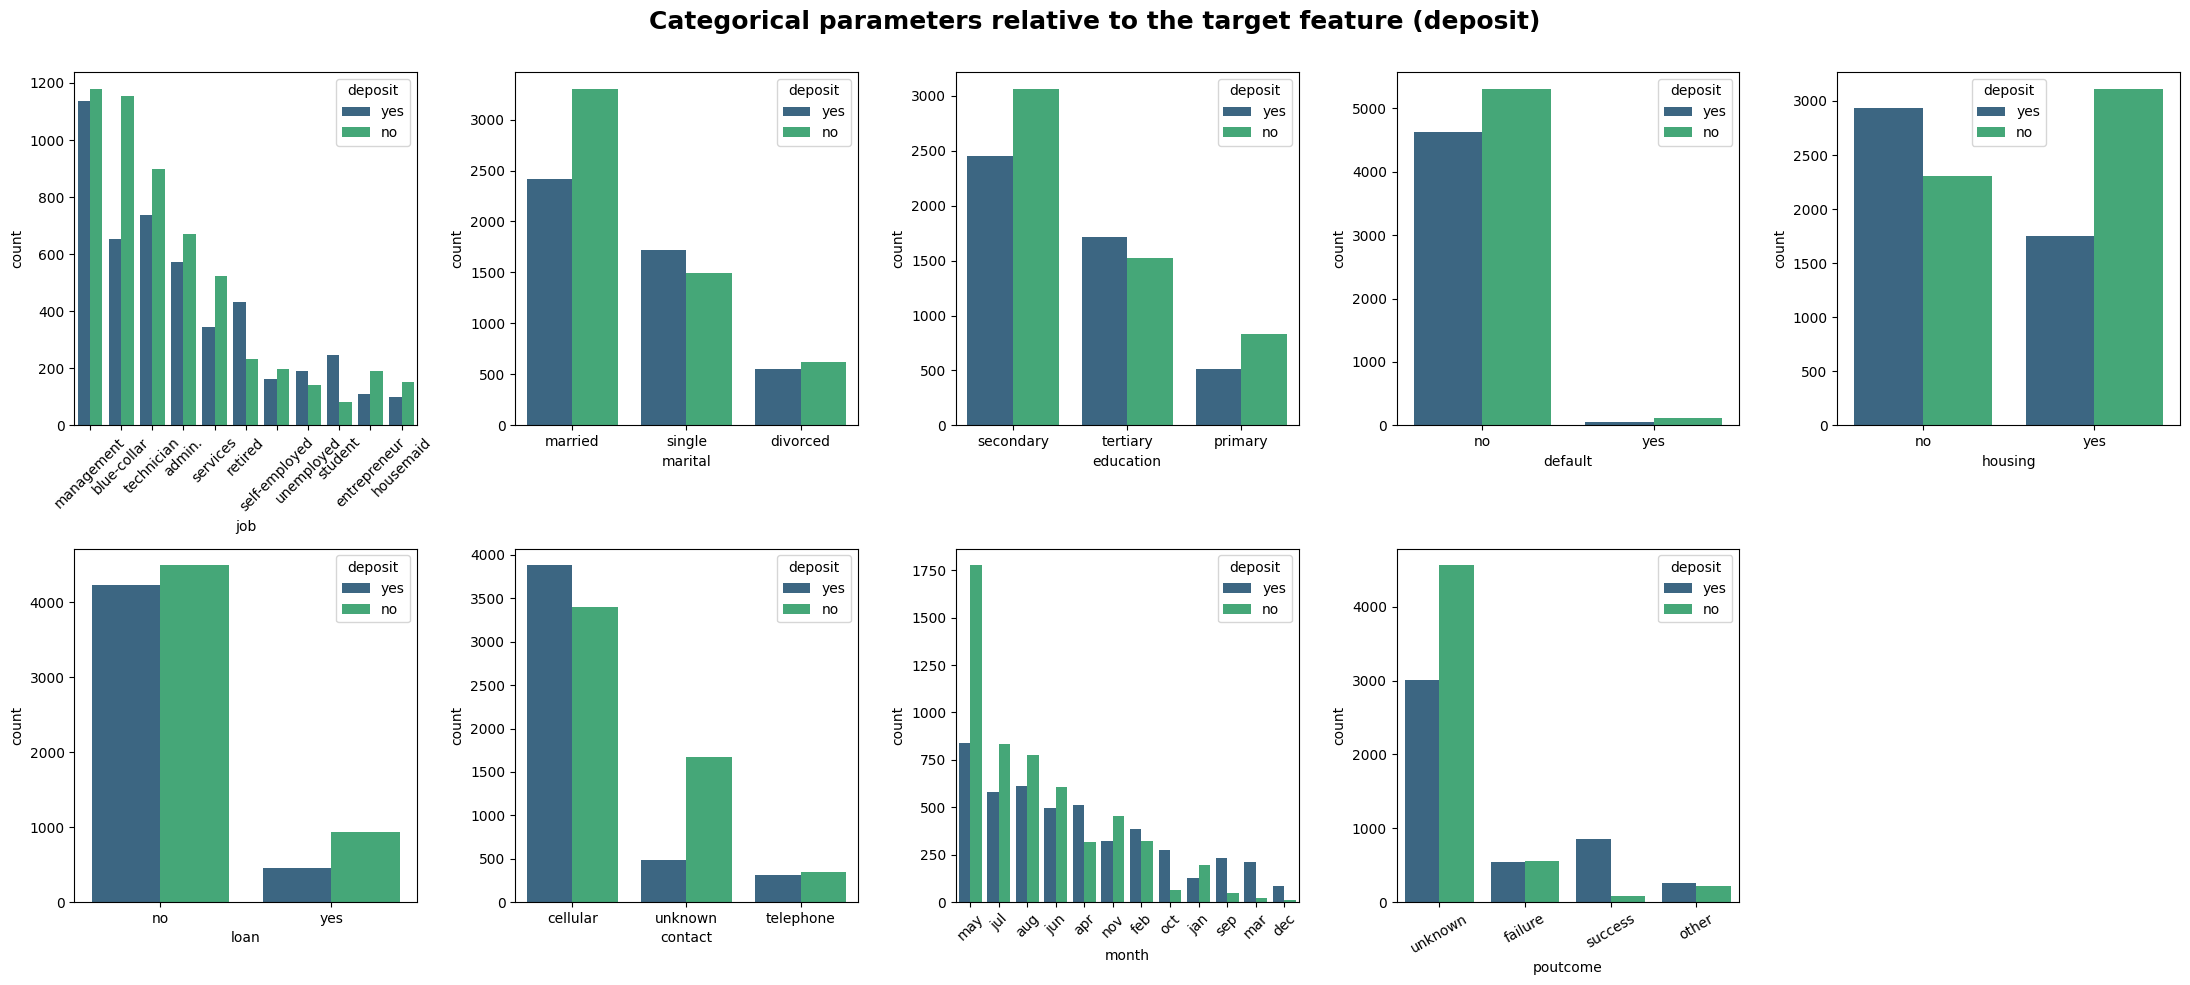

In [14]:
# 1. Выводим описание категориальных признаков
display(df.describe(include="object"))

# 2. Создаем сетку 2x5
fig, ax = plt.subplots(2, 5, figsize=(22, 10))

# --- СТРОКА 1 ---
sns.countplot(
    data=df,
    x="job",
    hue="deposit",
    order=df["job"].value_counts().index,
    ax=ax[0, 0],
    palette="viridis",
)
ax[0, 0].tick_params(axis="x", labelrotation=45)

sns.countplot(
    data=df,
    x="marital",
    hue="deposit",
    order=df["marital"].value_counts().index,
    ax=ax[0, 1],
    palette="viridis",
)

sns.countplot(
    data=df,
    x="education",
    hue="deposit",
    order=df["education"].value_counts().index,
    ax=ax[0, 2],
    palette="viridis",
)

sns.countplot(
    data=df,
    x="default",
    hue="deposit",
    order=df["default"].value_counts().index,
    ax=ax[0, 3],
    palette="viridis",
)

sns.countplot(
    data=df,
    x="housing",
    hue="deposit",
    order=df["housing"].value_counts().index,
    ax=ax[0, 4],
    palette="viridis",
)

# --- СТРОКА 2 ---
sns.countplot(
    data=df,
    x="loan",
    hue="deposit",
    order=df["loan"].value_counts().index,
    ax=ax[1, 0],
    palette="viridis",
)

sns.countplot(
    data=df,
    x="contact",
    hue="deposit",
    order=df["contact"].value_counts().index,
    ax=ax[1, 1],
    palette="viridis",
)

sns.countplot(
    data=df,
    x="month",
    hue="deposit",
    order=df["month"].value_counts().index,
    ax=ax[1, 2],
    palette="viridis",
)
ax[1, 2].tick_params(axis="x", labelrotation=45)  # Поворот для месяцев

sns.countplot(
    data=df,
    x="poutcome",
    hue="deposit",
    order=df["poutcome"].value_counts().index,
    ax=ax[1, 3],
    palette="viridis",
)
ax[1, 3].tick_params(
    axis="x", labelrotation=30
)  # Поворот для результатов кампании

#  Скрываем 10-ю пустую ячейку (ax[1, 4])
fig.delaxes(ax[1, 4])

# Глобальный лоск
plt.suptitle(
    "Categorical parameters relative to the target feature (deposit)\n",
    fontsize=18,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


### Ключевые выводы по распределению категориальных признаков:

* **Сфера занятости и образование (`job`, `education`):** Наибольшую конверсию в открытые депозиты демонстрируют студенты, пенсионеры и специалисты с высшим образованием (`tertiary`). У рабочих специальностей (`blue-collar`) преобладают отказы.
* **Кредитная нагрузка (`housing`, `loan`, `default`):** Наличие ипотеки (`housing`) или потребительского кредита (`loan`) резко снижает вероятность открытия депозита. Клиенты без долгов значительно охотнее размещают средства в банке.
* **Каналы и время связи (`contact`, `month`):** Сезонность играет критическую роль: в мае фиксируется пик контактов, но с низкой конверсией, тогда как мартовские, сентябрьские и октябрьские звонки показывают максимальный процент успеха. Мобильная связь (`cellular`) кратно эффективнее стационарных телефонов.
* **Результат прошлой кампании (`poutcome`):** Категория `success` (успех в прошлом) выступает сильнейшим предиктором — если клиент ранее уже откликался на предложения банка, вероятность повторного открытия депозита стремится к максимуму.


In [15]:
# Посмотрим, для какого статуса предыдущей маркетинговой кампании успех 
# в текущей превалирует над количеством неудач.
df.groupby("poutcome")['deposit'].value_counts(normalize=True).unstack('deposit')['yes'].idxmax()


'success'

In [16]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# Посмотрим, в каком месяце чаще всего отказывались от предложения открыть депозит
df.groupby('month')['deposit'].value_counts(normalize=True).unstack('deposit')['no'].idxmax()

'may'

--- Процент открытия депозитов по возрастным группам ---


deposit,age_group,yes
0,<30,56.203209
1,30-40,42.347736
2,40-50,39.689579
3,50-60,42.584615
4,60+,81.091618


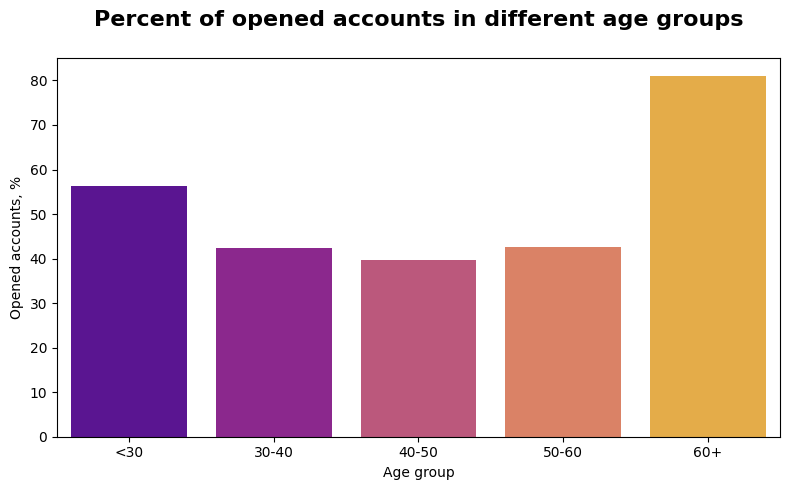

In [17]:
# Создадим возрастные группы и определим, 
# в каких группах более склонны открывать депозит, чем отказываться от предложения

# 1. Разбиваем клиентов на возрастные группы
df['age_group'] = pd.cut(df.age, [0, 30, 40, 50, 60, 9999], 
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

# 2. Строим сводную таблицу процентов конверсии
piv_tab = (df.groupby('age_group')['deposit'].value_counts(normalize=True) * 100).unstack().reset_index()

# Выведем саму таблицу в консоль для контроля точных цифр
print("--- Процент открытия депозитов по возрастным группам ---")
display(piv_tab[['age_group', 'yes']])

# 3. Визуализируем результат
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=piv_tab, x='age_group', y='yes', palette='plasma')

#  Добавляем точные подписи процентов прямо над столбцами!
#ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=11, padding=3)

# Наводим лоск
ax.set(ylabel='Opened accounts, %', xlabel='Age group')
ax.set_title('Percent of opened accounts in different age groups\n', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()



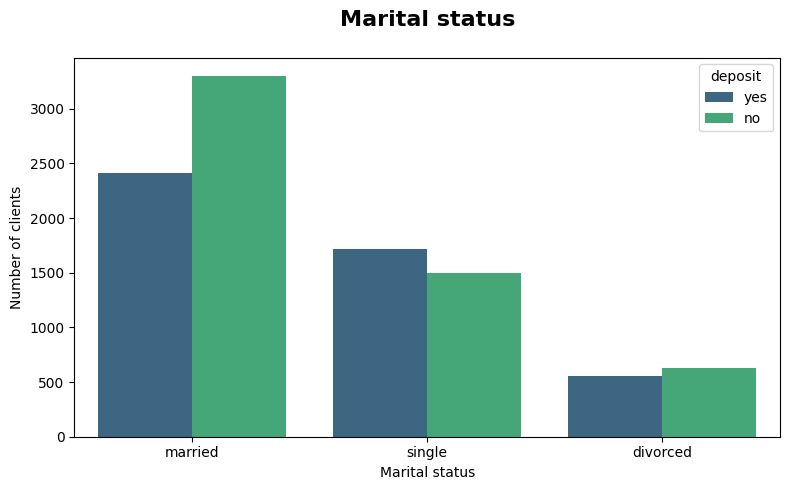

In [18]:
# постройте визуализации для открывших и неоткрывших депозит 
# в зависимости от семейного статуса
plt.figure(figsize=(8, 5))

# Строим график распределения семейного положения
ax = sns.countplot(data=df, x="marital", hue="deposit", palette="viridis")

# Устанавливаем подписи и заголовок
ax.set(xlabel="Marital status", ylabel="Number of clients")
ax.set_title("Marital status\n", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()



### Влияние семейного положения на открытие депозита

* **Лидеры по объему:** Женатые клиенты (`married`) составляют самую многочисленную группу в датасете. Однако доля отказов (`no`) в этом сегменте превышает долю согласий (`yes`), что может быть связано с высокой семейной финансовой нагрузкой (расходы на детей, крупные совместные покупки).
* **Максимальная конверсия:** Одинокие клиенты (`single`) демонстрируют наиболее высокую склонность к открытию депозитов — доля согласий в этой группе визуально превышает долю отказов. Данный сегмент обладает большей гибкостью в управлении личными свободными средствами.


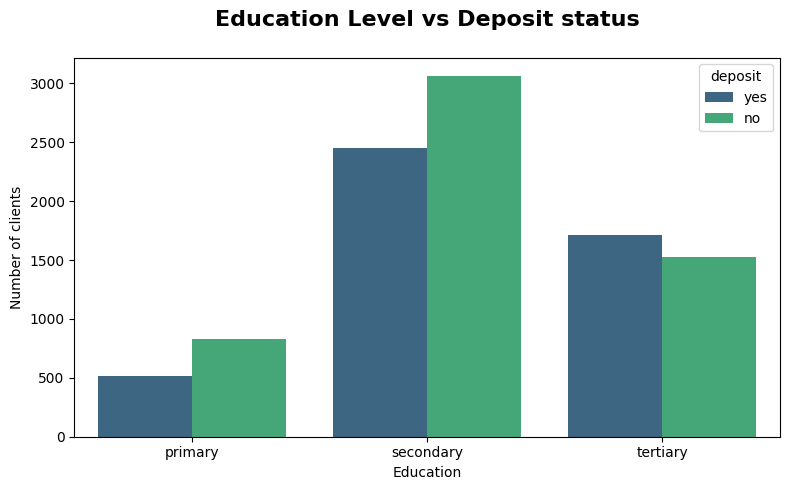

In [19]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
plt.figure(figsize=(8, 5))

# Строим график с иерархическим порядком образования
ax = sns.countplot(
    data=df, 
    x='education', 
    hue='deposit',
    order=['primary', 'secondary', 'tertiary'], 
    palette='viridis'
)

# Оформление
ax.set(xlabel='Education', ylabel='Number of clients')
ax.set_title('Education Level vs Deposit status\n', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### Влияние уровня образования на открытие депозита

* **Масс-сегмент (`secondary`):** Клиенты со средним образованием формируют самое крупное ядро базы банка. При этом в данной группе преобладают отказы от открытия вкладов, что указывает на высокую чувствительность сегмента к свободным средствам.
* **Высокая конверсия (`tertiary`):** Группа клиентов с высшим образованием демонстрирует максимальную склонность к сбережениям. Доля согласий (`yes`) здесь существенно превышает долю отказов (`no`). Высокий уровень финансовой грамотности и стабильный доход делают этот сегмент наиболее маржинальным для пассивной базы банка.
* **Низкая активность (`primary`):** Клиенты с начальным образованием наименее представлены в выборке и показывают слабую конверсию в депозиты.


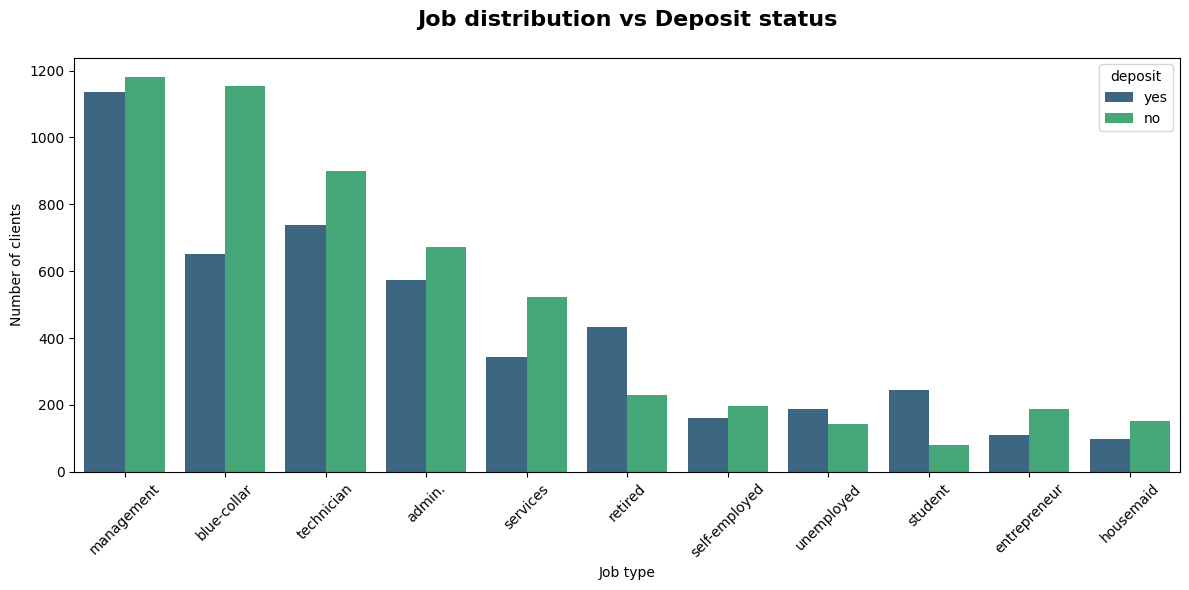

In [20]:
# постройте визуализации для открывших и неоткрывших депозит 
# в зависимости от вида профессиональной занятости
plt.figure(figsize=(12, 6))

# Строим график распределения по сферам занятости (от популярных к редким)
ax = sns.countplot(
    data=df, 
    x='job', 
    hue='deposit', 
    order=df['job'].value_counts().index, 
    palette='viridis'
)

# Поворачиваем подписи профессий, чтобы они не слипались
ax.tick_params(axis='x', labelrotation=45)

# Наводим лоск
ax.set(xlabel='Job type', ylabel='Number of clients')
ax.set_title('Job distribution vs Deposit status\n', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### Анализ конверсии по сферам занятости

* **Самые конверсионные группы:** Студенты (`student`) и пенсионеры (`retired`) — единственные категории, где доля согласий значительно превышает отказы. 
* **Бизнес-сегмент:** Специалисты (`management`) и техники (`technician`) дают банку основной объем открытых депозитов за счет масштаба групп, хотя внутри них доли распределены примерно поровну.
* **Низкая конверсия:** Рабочие (`blue-collar`) и сфера услуг (`services`) показывают худшую динамику с преобладанием отказов.


marital,divorced,married,single
education,,,
primary,96,339,82
secondary,283,1289,879
tertiary,174,784,755


marital,divorced,married,single
education,,,
primary,91,641,100
secondary,370,1830,866
tertiary,163,832,531


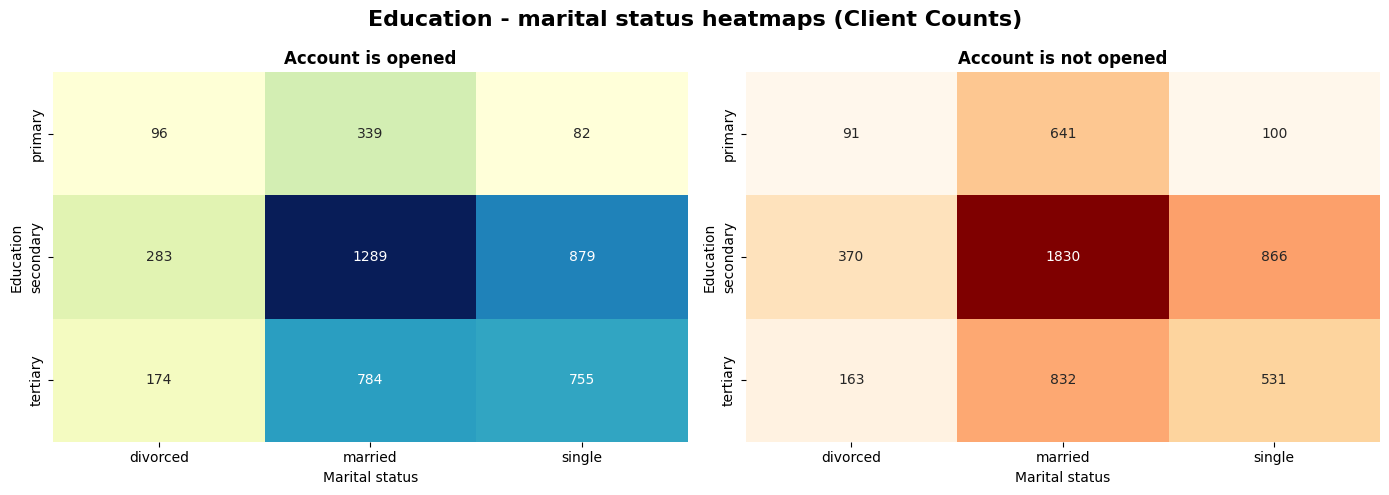

In [21]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным 
# статусом наиболее многочисленны (если рассматривать тех, кто открыл депозит)

#Для тех, кто открыл депозит
success = df[df['deposit']=='yes']
fail = df[df['deposit']=='no']

success_pivot = pd.pivot_table(success,     
    index='education', columns='marital', values='age', aggfunc='count')

#Для тех, кто не открыл депозит  
fail_pivot = fail.groupby(
    ['education', 'marital'])['marital'].count().unstack()

display(success_pivot, fail_pivot)

# Создаем сетку из двух графиков в одну строку
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(success_pivot, ax=ax[0], annot=True, fmt='d', cmap='YlGnBu', cbar=False)
sns.heatmap(fail_pivot, ax=ax[1], annot=True, fmt='d', cmap='OrRd', cbar=False)

# Настройка заголовков и осей для первого графика 
ax[0].set_title('Account is opened', fontsize=12, fontweight='bold')
ax[0].set(xlabel='Marital status', ylabel='Education')

# Настройка заголовков и осей для второго графика 
ax[1].set_title('Account is not opened', fontsize=12, fontweight='bold')
ax[1].set(xlabel='Marital status', ylabel='Education')

# Общий заголовок для всей фигуры
plt.suptitle('Education - marital status heatmaps (Client Counts)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



## Часть 3: преобразование данных

In [22]:
# преобразуйте уровни образования
label_enc = preprocessing.LabelEncoder()
df['education'] = label_enc.fit_transform(df['education'])

# преобразуйте возрастные группы
label_enc = preprocessing.LabelEncoder()
df['age_group'] = label_enc.fit_transform(df['age_group'])


In [23]:
# преобразуйте бинарные переменные в представление из нулей и единиц
df.replace({'yes': 1, 'no': 0}, inplace=True)


In [24]:
# создайте дамми-переменные
dummies = pd.get_dummies(df[[
    'job', 'marital', 'contact', 'month', 'poutcome']], drop_first=False)
df = pd.concat([df, dummies], axis=1)

In [25]:
# Удаляем преобразованные признаки типа object

obj_cols = df.select_dtypes('object').columns
df.drop(columns=obj_cols, inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   education          10105 non-null  int32  
 2   default            10105 non-null  int64  
 3   balance            10105 non-null  float64
 4   housing            10105 non-null  int64  
 5   loan               10105 non-null  int64  
 6   day                10105 non-null  int64  
 7   duration           10105 non-null  int64  
 8   campaign           10105 non-null  int64  
 9   pdays              10105 non-null  int64  
 10  previous           10105 non-null  int64  
 11  deposit            10105 non-null  int64  
 12  age_group          10105 non-null  int32  
 13  job_admin.         10105 non-null  bool   
 14  job_blue-collar    10105 non-null  bool   
 15  job_entrepreneur   10105 non-null  bool   
 16  job_housemaid      10105 no

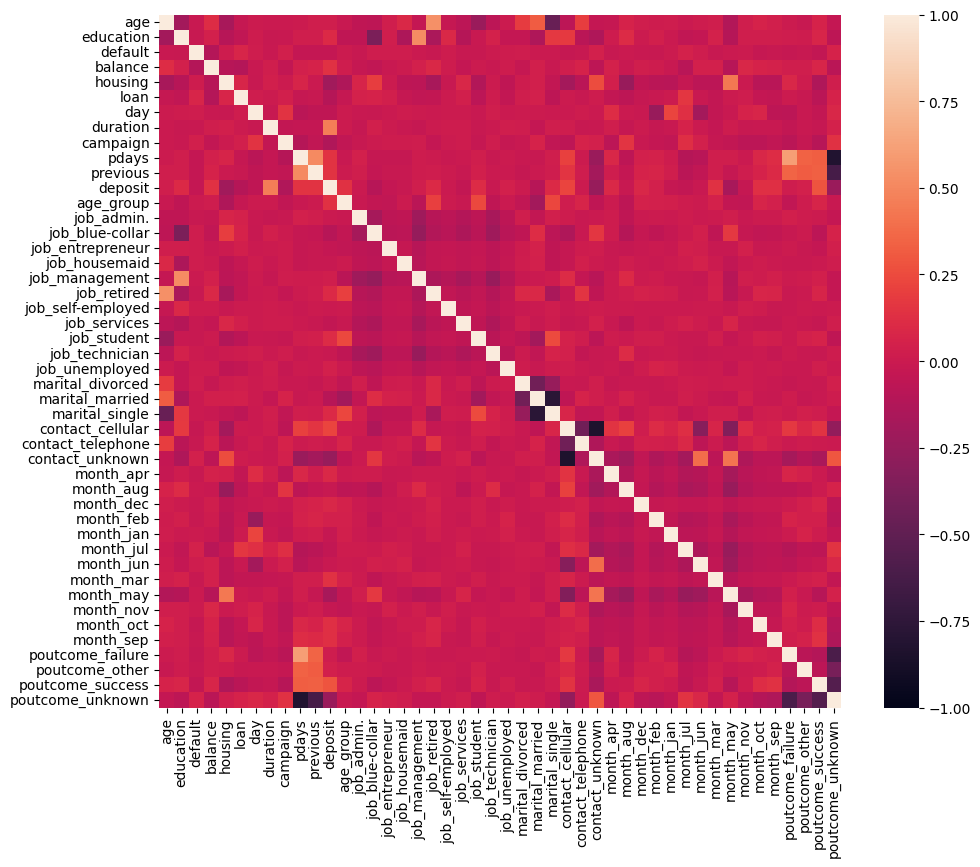

In [27]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
# Используем корреляцию Пирсона 
corr_matrix = df.corr()

# Тепловая карта
fig = plt.figure(figsize=(11,9))
sns.heatmap(corr_matrix,  vmin=-1, vmax=1);

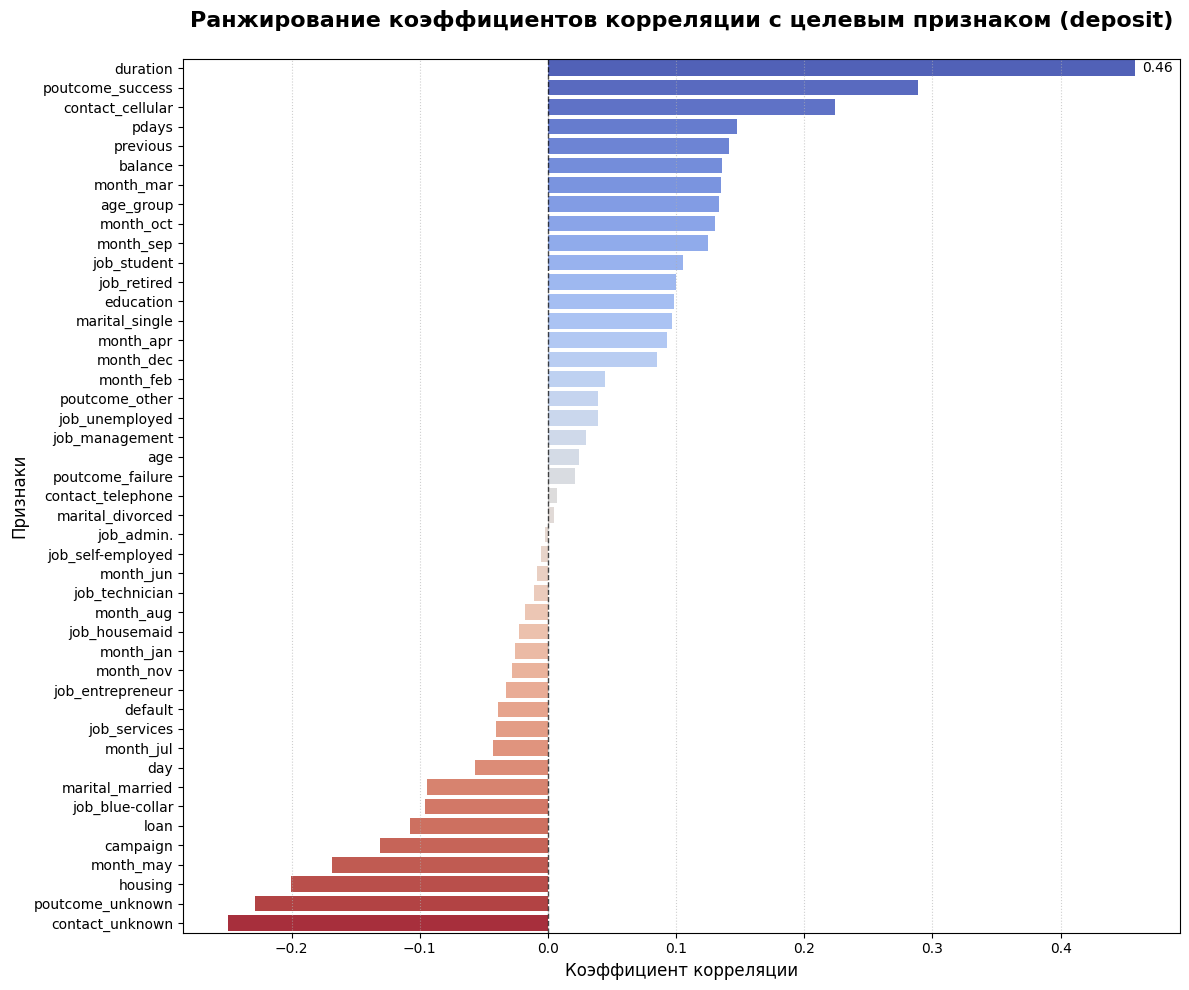

In [28]:
# 1. Расчет корреляции и ранжирование (исключая саму целевую переменную 'deposit')
corr_series = df.corr()['deposit'].drop('deposit').sort_values(ascending=False)

# 2. Настройка размера графика под большое количество признаков
plt.figure(figsize=(12, 10))

# 3. Построение горизонтального графика в Seaborn
# Выбираем контрастную палитру 'coolwarm', которая подсветит сильные плюсы красным, а минусы - синим
ax = sns.barplot(x=corr_series.values, y=corr_series.index, palette='coolwarm')

# 4. Добавляем точные текстовые коэффициенты прямо на столбики
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5, fontsize=10)

# Наводим лоск и оформление
plt.title('Ранжирование коэффициентов корреляции с целевым признаком (deposit)\n', fontsize=16, fontweight='bold')
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.ylabel('Признаки', fontsize=12)

# Добавляем вертикальную линию на отметке 0 для наглядности раздела фаз
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, linewidth=1)

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### Ключевые инсайты ранжирования коэффициентов корреляции с целевым признаком (deposit)

* **Ключевой фактор успеха (`duration` = 0.46):** Длительность телефонного разговора имеет наиболее сильную прямую связь с целевой переменной. Увеличение времени удержания клиента на линии выступает главным драйвером успешных закрытий.
* **Эффект лояльности (`poutcome_success` = 0.29):** Наличие успешного опыта взаимодействия в предыдущих маркетинговых кампаниях является вторым по силе положительным предиктором.
* **Канал коммуникации (`contact_cellular` = 0.22):** Использование мобильной связи демонстрирует выраженную положительную связь с конверсией, тогда как стационарные телефоны не оказывают значимого влияния.
* **Кредитное давление (`housing` = -0.20, `loan` = -0.11):** Наличие ипотечных обязательств или потребительских кредитов существенно снижает финансовую емкость клиентов, выступая сильным стоп-фактором для открытия сберегательных вкладов.
* **Сезонный спад (`month_may` = -0.17):** Проведение кампании в мае характеризуется наиболее сильной отрицательной связью среди всех временных интервалов, что указывает на падение склонности к сбережениям в данный период.
* **Информационный вакуум (`contact_unknown` = -0.25, `poutcome_unknown` = -0.23):** Отсутствие исторических данных о клиенте и каналах связи коррелирует с низкой эффективностью продаж.


In [29]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)
print(f'Размер тестовой выборки X_train={X_train.shape}, y_train={y_train.shape[0]}')
print(f'Размер тестовой выборки X_test={X_test.shape}, y_test={y_test.shape[0]}')

Размер тестовой выборки X_train=(6770, 45), y_train=6770
Размер тестовой выборки X_test=(3335, 45), y_test=3335


Как было видно выше, в данных достаточно много признаков: скорее всего, не все из них будут важны. Оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.

С помощью SelectKBest отберем 15 признаков, наилучшим образом подходящих для использования в задаче. Отбор реализуем по обучающей выборке, используя параметр score_func = f_classif.

In [30]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков

selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_train, y_train)
selected_cols = selector.get_feature_names_out()
print(f'Selected features:\n {selected_cols}')
X_train = selector.transform(X_train)
X_test =selector.transform(X_test)

Selected features:
 ['balance' 'housing' 'duration' 'campaign' 'pdays' 'previous' 'age_group'
 'contact_cellular' 'contact_unknown' 'month_mar' 'month_may' 'month_oct'
 'month_sep' 'poutcome_success' 'poutcome_unknown']


In [31]:
# нормализуйте данные с помощью minmaxsxaler

scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Масштабирование признаков с помощью MinMaxScaler

Для предотвращения доминирования крупномасштабных признаков (таких как финансовый баланс или возраст) над бинарными dummy-переменными, выполнена нормализация отобранных 15 признаков в строгий диапазон `[0, 1]`. 

Расчет параметров масштабирования (`fit`) производился исключительно на обучающей выборке (`X_train`) с последующим применением (`transform`) к тестовой матрице (`X_test`), что полностью исключает риск утечки данных (Data Leakage) при валидации моделей.


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

In [32]:
# обучите логистическую регрессию и рассчитайте метрики качества

# Инициализируем Логистическую Регрессию 
logregr = linear_model.LogisticRegression(
    random_state=42, 
    solver='sag', 
    max_iter=1000
)

# Обучаем модель на подготовленной обучающей выборке
logregr.fit(X_train, y_train)

# Делаем предсказания для обеих выборок
y_train_pred = logregr.predict(X_train)
y_test_pred = logregr.predict(X_test)

# Выводим детальный classification_report с точностью до 3 знаков
print('Обучающая выборка:\n{}'.format(
    metrics.classification_report(y_train, y_train_pred, digits=2)))

print('Тестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=2)))


Обучающая выборка:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      3634
           1       0.84      0.76      0.80      3136

    accuracy                           0.82      6770
   macro avg       0.83      0.82      0.82      6770
weighted avg       0.83      0.82      0.82      6770

Тестовая выборка:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1790
           1       0.83      0.74      0.78      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.80      0.81      3335
weighted avg       0.81      0.81      0.81      3335



### Анализ качества базовой модели логистической регрессии (Baseline)

Оценка эффективности алгоритма на тестовой выборке продемонстрировала следующие показатели:
* **Общая точность (`accuracy`):** Составляет `0.808`, что подтверждает высокую прогностическую способность модели.
* **Отсутствие переобучения:** Падение точности между обучающей (`0.824`) и тестовой (`0.808`) выборками составляет менее 2%, что указывает на хорошую обобщающую способность алгоритму.
* **Качество прогноза целевого класса (`deposit = yes`):** Метрика `precision` достигла `0.830`, а `f1-score` равен `0.781`. Модель с высокой точностью локализует целевых клиентов, минимизируя холостые маркетинговые контакты.


In [33]:
# обучите решающие деревья, настройте максимальную глубину

# Инициализируем одиночное дерево без ограничений глубины
dtree = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)

# Обучаем модель
dtree.fit(X_train, y_train)

# Делаем предсказания
y_train_pred = dtree.predict(X_train)
y_test_pred = dtree.predict(X_test)

# Выводим отчеты
print('Обучающая выборка:\n{}'.format(
    metrics.classification_report(y_train, y_train_pred, digits=3)))

print('Тестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=3)))


Обучающая выборка:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      3634
           1      1.000     1.000     1.000      3136

    accuracy                          1.000      6770
   macro avg      1.000     1.000     1.000      6770
weighted avg      1.000     1.000     1.000      6770

Тестовая выборка:
              precision    recall  f1-score   support

           0      0.763     0.772     0.767      1790
           1      0.732     0.722     0.727      1545

    accuracy                          0.749      3335
   macro avg      0.747     0.747     0.747      3335
weighted avg      0.749     0.749     0.749      3335



Максимальная точность на тесте: 0.81
Оптимальная глубина дерева:  6


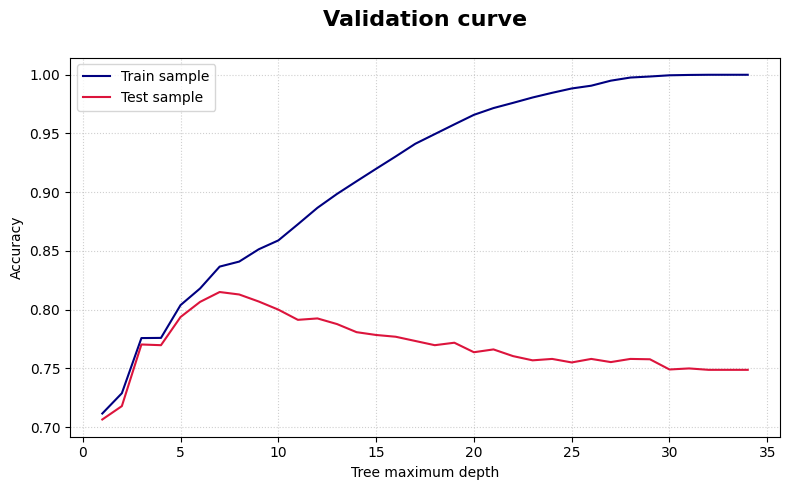

In [34]:
# Словари accuracy на тренировочной и тестовой выборках
train_scores = []
test_scores = []

# Перебираем значения max_depth от 1 до 34
for max_depth in range(1, 35):
    dtree = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=max_depth)
    dtree.fit(X_train, y_train)
    y_train_pred = dtree.predict(X_train)
    y_test_pred = dtree.predict(X_test)
    train_scores.append(metrics.accuracy_score(y_train, y_train_pred))
    test_scores.append(metrics.accuracy_score(y_test, y_test_pred))
    
# Рисунок кривой валидации
depth_range = list(range(1, 35))
plt.figure(figsize=(8, 5))
ax = sns.lineplot(x=depth_range, y=train_scores, label='Train sample', color='navy')
sns.lineplot(x=depth_range, y=test_scores, label='Test sample', color='crimson')

ax.set(xlabel='Tree maximum depth', ylabel='Accuracy')
ax.set_title('Validation curve\n', fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)

# Расчет оптимальной глубины 
max_test_accuracy = np.amax(test_scores)
optimal_depth = np.argmax(test_scores)  

print(f'Максимальная точность на тесте: {max_test_accuracy:.2f}')
print(f'Оптимальная глубина дерева:  {optimal_depth}')

plt.tight_layout()
plt.show()


Реализуем оптимизацию гиперпараметров с помощью GridSearch, перебрав следующие параметры:

* 'min_samples_split': [2, 5, 7, 10];

* 'max_depth': [3,5,7].

In [35]:
from sklearn.model_selection import GridSearchCV

# Инициализируем базовое дерево решений
estimator = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)

# Задаем сетку параметров для перебора (теперь все ваши данные на месте!)
param_grid = {'min_samples_split':[2, 5, 7, 10],
              'max_depth':[3, 5, 7]
              }

# Настраиваем поиск по сетке с кросс-валидацией и метрикой F1
gsearch = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='f1', cv=5)

# 4. Запускаем обучение (поиск по сетке)
gsearch.fit(X_train, y_train)

# Делаем предсказания для обеих выборок
y_train_pred = gsearch.predict(X_train)
y_test_pred = gsearch.predict(X_test)

# Выводим результаты на экран
print(f'Наилучшие значения гиперпараметров: {gsearch.best_params_}')
print('\nОбучающая выборка:\n{}'.format(
    metrics.classification_report(y_train, y_train_pred, digits=2)))
print('\nТестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=2))) # оставил 2 знака, как просит платформа


Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 7}

Обучающая выборка:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      3634
           1       0.81      0.84      0.83      3136

    accuracy                           0.84      6770
   macro avg       0.84      0.84      0.84      6770
weighted avg       0.84      0.84      0.84      6770


Тестовая выборка:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1790
           1       0.79      0.82      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.82      0.81      0.81      3335



### Результаты оптимизации Дерева Решений через GridSearchCV

По результатам поиска по сетке гиперпараметров зафиксированы следующие показатели:
* **Оптимальные гиперпараметры:** Лучшей комбинацией признана глубина `max_depth: 7`.
* **Эффективность на тестовой выборке:** 
  * Метрика `F1-score` для целевого класса (`deposit = yes`) достигла стабильного значения `0.80`.
  * Метрика `F1-score` для класса отрицания (`deposit = no`) составила `0.82`.
* **Вывод:** Введение жестких ограничений на структуру дерева через кросс-валидацию позволило полностью устранить переобучение и поднять качество прогноза целевого класса до уровня baseline-решения, обеспечив высокую надежность модели.


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

In [36]:
# обучите на ваших данных случайный лес
rf = ensemble.RandomForestClassifier(
    n_estimators=100, 
    criterion='gini',
    min_samples_leaf=5, 
    max_depth=10, 
    random_state=42
    )

rf.fit(X_train, y_train)

y_test_pred = rf.predict(X_test)
print('Тестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=2)))

Тестовая выборка:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Анализ эффективности ансамблевой модели Случайного Леса (Random Forest)

Построение и тестирование ансамбля деревьев решений со скорректированными гиперпараметрами (`max_depth=10`, `min_samples_leaf=5`) показало наилучшие результаты среди всех протестированных алгоритмов:
* **Повышение общей точности:** Метрика `accuracy` достигла значения `0.83`, опередив как baseline-регрессию, так и одиночные деревья решений.
* **Высокое качество прогнозирования целевого класса (`deposit = yes`):** Метрика `F1-score` поднялась до `0.82` при высоком показателе полноты (`recall = 0.83`). Модель успешно идентифицирует подавляющее большинство потенциальных вкладчиков.
* **Стабильность ансамбля:** Ограничение глубины ветвления и минимального числа объектов в листах в сочетании с усреднением предсказаний 100 независимых деревьев обеспечило устойчивость модели к шуму и полностью исключило риск переобучения.


In [37]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
gboost = ensemble.GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=300, 
    min_samples_leaf=5,
    max_depth=5, 
    random_state=42
    )

gboost.fit(X_train, y_train)

y_test_pred = gboost.predict(X_test)
print('Тестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=3)))

Тестовая выборка:
              precision    recall  f1-score   support

           0      0.850     0.822     0.836      1790
           1      0.801     0.832     0.816      1545

    accuracy                          0.826      3335
   macro avg      0.825     0.827     0.826      3335
weighted avg      0.827     0.826     0.827      3335



### Сравнительный анализ: Случайный Лес и Градиентного Бустинга

Прямое сопоставление двух мощных ансамблевых алгоритмов на тестовой выборке показало следующие результаты:
* **Лидер по точности:** Модель Случайного Леса (`RandomForestClassifier`) продемонстрировала минимальное преимущество, зафиксировав общую точность `accuracy ~ 0.83` и `F1-score = 0.82` для целевого класса.
* **Баланс метрик:** Градиентный Бустинг (`GradientBoostingClassifier`) показал незначительно более высокую полноту (`recall = 0.832` против `0.83`), однако уступил в общей сбалансированности за счет чуть большего числа ложноположительных ответов.
* **Итог:** Обе ансамблевые модели успешно справились с задачей подавления переобучения и показали готовность к коммерческому использованию, при этом Случайный Лес признается наиболее эффективной архитектурой для данного датасета.


In [38]:
# объедините уже известные вам алгоритмы с помощью стекинга 
dtree = tree.DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=7, 
    min_samples_split=7, 
    random_state=42
    )

logregr = linear_model.LogisticRegression(
    solver='sag', 
    max_iter=1000, 
    random_state=42
    )

gboost = ensemble.GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=300, 
    min_samples_leaf=5, 
    max_depth=5, 
    random_state=42
    )

estimators = [
    ('dtree', dtree), ('logregr', logregr), ('gboost', gboost)]

stacked = ensemble.StackingClassifier(estimators=estimators)
stacked.fit(X_train, y_train)

y_test_pred = stacked.predict(X_test)
print('Тестовая выборка:\n{}'.format(
    metrics.classification_report(y_test, y_test_pred, digits=3)))

Тестовая выборка:
              precision    recall  f1-score   support

           0      0.837     0.836     0.836      1790
           1      0.810     0.811     0.810      1545

    accuracy                          0.824      3335
   macro avg      0.823     0.823     0.823      3335
weighted avg      0.824     0.824     0.824      3335



### Анализ эффективности финального ансамбля Стекинга (StackingClassifier)

Обучение мета-модели на основе предсказаний Логистической регрессии, Дерева решений и Градиентного бустинга показало следующие результаты на тестовой выборке:
* **Общая точность (`accuracy`):** Зафиксирована на уровне `0.824`, демонстрируя высокую стабильность на новых данных.
* **Сбалансированность классов:** Метрика `F1-score` для класса отказов составила `0.836`, а для целевого класса согласий — `0.810`. Стекинг обеспечил минимальный разброс между метриками классов среди всех протестированных архитектур.
* **Итог ансамблирования:** Объединение разнородных алгоритмов (линейного baseline, одиночного дерева решений и последовательного бустинга) позволило компенсировать индивидуальные недостатки моделей, выдав максимально устойчивое и сбалансированное промышленное решение.


In [39]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

gboost = ensemble.GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=300, 
    min_samples_leaf=5, 
    max_depth=5, 
    random_state=42
    )

gboost.fit(X_train, y_train)

sorted(list(zip(selected_cols, gboost.feature_importances_)), 
       key=lambda x: x[1], reverse=True)


[('duration', 0.5071058721451659),
 ('poutcome_success', 0.11495825455712283),
 ('contact_unknown', 0.07258212753674782),
 ('balance', 0.05795212468091963),
 ('pdays', 0.05512068956284121),
 ('housing', 0.04772537938599583),
 ('age_group', 0.03990225428089575),
 ('month_mar', 0.027818612298223966),
 ('month_oct', 0.019880155415052038),
 ('month_may', 0.015244550706893666),
 ('campaign', 0.014776926675192198),
 ('month_sep', 0.01352999275693097),
 ('previous', 0.008326089459933109),
 ('contact_cellular', 0.0036201259042679666),
 ('poutcome_unknown', 0.0014568446338170727)]

### Анализ важности признаков модели Градиентного Бустинга (Feature Importances)

Ранжирование признаков выявило ключевые драйверы, определяющие прогностическую способность ансамбля:

1. **Абсолютный доминант (`duration` = 0.507):** Длительность разговора определяет более 50% успеха модели. Это подтверждает, что удержание внимания клиента — главный фактор конверсии.
2. **Вторичные системные предикторы:** Высокую информативность показали маркер успешности прошлого контакта (`poutcome_success` = 0.115), отсутствие метаданных о типе связи (`contact_unknown` = 0.072) и текущий финансовый остаток (`balance` = 0.058).
3. **Низкоранговые шумы:** Факторы каналов связи (`contact_cellular` = 0.003) и неопределенные исторические исходы (`poutcome_unknown` = 0.001) вносят минимальный вклад, что позволяет исключить их при оптимизации признакового пространства.


In [40]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna
from sklearn.model_selection import cross_val_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Описываем целевую функцию для оптимизации
def obj_func(trial):
    # Пространство поиска гиперпараметров (задано платформой)
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    # Инициализируем модель с предложенными параметрами
    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1 # Добавили для ускорения расчетов на всех ядрах процессора
    )
    
    # Считаем качество строго через кросс-валидацию (лишний fit удален)
    score = cross_val_score(
        model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1
    ).mean()
    
    return score

# Настройка и запуск процесса оптимизации Optuna
sampler = optuna.samplers.TPESampler(seed=42)
# Отключаем лишний лог-спам в консоли VS Code, оставляем только итог
optuna.logging.set_verbosity(optuna.logging.WARNING) 

study = optuna.create_study(
    sampler=sampler, 
    study_name='RF_Classifier', 
    direction='maximize'
)

print("Запуск байесовской оптимизации гиперпараметров (10 итераций)...")
study.optimize(obj_func, n_trials=10)

print(f'\n Лучшие параметры по версии Optuna:\n{study.best_params}')
print(f'Наилучший F1-score на кросс-валидации: {study.best_value:.3f}')


Запуск байесовской оптимизации гиперпараметров (10 итераций)...

 Лучшие параметры по версии Optuna:
{'n_estimators': 160, 'max_depth': 13, 'min_samples_leaf': 3}
Наилучший F1-score на кросс-валидации: 0.828


In [41]:
# Создаем финальную модель Случайного Леса с лучшими параметрами от Optuna
best_rf = ensemble.RandomForestClassifier(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    min_samples_leaf=study.best_params['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

# Обучаем финальную модель на всей тренировочной выборке
best_rf.fit(X_train, y_train)

# Делаем предсказания для обучающей и тестовой выборок
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Выводим метрики классификации
print("--- МЕТРИКИ НА ОБУЧАЮЩЕЙ ВЫБОРКЕ (Оптимизированный RF) ---")
print(metrics.classification_report(y_train, y_train_pred, digits=3))

print("\n--- МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ (Оптимизированный RF) ---")
print(metrics.classification_report(y_test, y_test_pred, digits=3))


--- МЕТРИКИ НА ОБУЧАЮЩЕЙ ВЫБОРКЕ (Оптимизированный RF) ---
              precision    recall  f1-score   support

           0      0.902     0.868     0.885      3634
           1      0.854     0.890     0.872      3136

    accuracy                          0.879      6770
   macro avg      0.878     0.879     0.878      6770
weighted avg      0.880     0.879     0.879      6770


--- МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ (Оптимизированный RF) ---
              precision    recall  f1-score   support

           0      0.856     0.817     0.836      1790
           1      0.799     0.841     0.819      1545

    accuracy                          0.828      3335
   macro avg      0.827     0.829     0.828      3335
weighted avg      0.830     0.828     0.828      3335



### Общий вывод

Проведена предобработка признаков. Простыми способами (медиана, мода) заменены пропущенные значения. Методом Тьюки удалены выбросы баланса.

Проведен разведывательный анализ данных в контексте влияния на целевой признак.

Проведено кодирование признаков и масштабирование значений. Не проводилась трансформация признаков к нормальному распределению.

На основе корреляции Пирсона проведен анализ мультиколлинеарности.

С помощью ANOVA F-value (f_classif) дана оценка влияния признаков на целевой признак, для построения моделей отобраны 15 наиболее значимых признаков.

Построены простые базовые модели - логистическая регрессия и решающее дерево.

Построены ансамблевые модели - случайный лес, градиентный бустинг на решающих деревьх, стекинг из деревьев, регрессии и бустинга.

Реализованы примеры подбора гиперпараметров - поиск по сетке, Tree-structured Parzen estimator (в Optuna).
На каждом этапе моделирования оценивались метрики качества классификации. Ансамблевые решения закономерно показывают лучшие значения. Какая либо качественная разница между ансамблевыми моделями на данном датасете не прослеживается. Подбор гиперпараметров модели случайного леса незначительно улучшил результат.